In [4]:
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    average_precision_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [5]:
data_path = Path("../data/processed/late_shipment_modeling.csv")

df = pd.read_csv(data_path)

print(df.shape)
df.head()

(7020, 11)


,shipment_id,late_flag,data_split,country,vendor,shipment_mode,scheduled_year,scheduled_month,line_item_count,total_line_item_value_usd,log_total_value_usd
0,ASN-10006,0,train,Haiti,BRISTOL-MYERS SQUIBB,Air,2011,4,1,1900.0,7.550135
1,ASN-10007,0,train,Haiti,BRISTOL-MYERS SQUIBB,Air,2011,4,2,3970.0,8.286773
2,ASN-10011,1,train,South Africa,ASPEN PHARMACARE,Air,2011,2,1,120240.0,11.697253
3,ASN-10012,0,train,South Africa,ASPEN PHARMACARE,Air,2011,3,1,400800.0,12.901220
4,ASN-10062,0,train,Haiti,"Orgenics, Ltd",Air,2011,4,1,195360.0,12.182604


In [6]:
df.groupby("data_split")["late_flag"].agg(
    total="count",
    late_shipments="sum",
    late_rate="mean"
)

,total,late_shipments,late_rate
data_split,,,
test,569,72,0.126538
train,5543,566,0.102111
validation,908,160,0.176211


In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

vendor_counts = (
    df.loc[df["data_split"] == "train", "vendor"]
    .value_counts()
)

common_vendors = vendor_counts[
    vendor_counts >= 20
].index

df["vendor_grouped"] = df["vendor"].where(
    df["vendor"].isin(common_vendors),
    "Other",
)

categorical_features = [
    "country",
    "vendor_grouped",
    "shipment_mode",
]

numeric_features = [
    "scheduled_month",
    "line_item_count",
    "log_total_value_usd",
]

feature_columns = categorical_features + numeric_features

train_df = df[df["data_split"] == "train"].copy()
validation_df = df[df["data_split"] == "validation"].copy()
test_df = df[df["data_split"] == "test"].copy()

X_train = train_df[feature_columns]
y_train = train_df["late_flag"]

X_validation = validation_df[feature_columns]
y_validation = validation_df["late_flag"]

X_test = test_df[feature_columns]
y_test = test_df["late_flag"]

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent"),
    ),
    (
        "onehot",
        OneHotEncoder(handle_unknown="ignore"),
    ),
])

numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median"),
    ),
    (
        "scaler",
        StandardScaler(),
    ),
])

preprocessor = ColumnTransformer([
    (
        "categorical",
        categorical_pipeline,
        categorical_features,
    ),
    (
        "numeric",
        numeric_pipeline,
        numeric_features,
    ),
])

baseline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=42,
        ),
    ),
])

baseline.fit(X_train, y_train)

validation_probabilities = baseline.predict_proba(
    X_validation
)[:, 1]

validation_predictions = (
    validation_probabilities >= 0.50
).astype(int)

print(
    classification_report(
        y_validation,
        validation_predictions,
        digits=3,
    )
)

print("Confusion matrix:")
print(
    confusion_matrix(
        y_validation,
        validation_predictions,
    )
)

print(
    "Validation ROC-AUC:",
    round(
        roc_auc_score(
            y_validation,
            validation_probabilities,
        ),
        3,
    ),
)

print(
    "Validation PR-AUC:",
    round(
        average_precision_score(
            y_validation,
            validation_probabilities,
        ),
        3,
    ),
)

              precision    recall  f1-score   support

           0      0.926     0.586     0.717       748
           1      0.287     0.781     0.420       160

    accuracy                          0.620       908
   macro avg      0.607     0.683     0.569       908
weighted avg      0.813     0.620     0.665       908

Confusion matrix:
[[438 310]
 [ 35 125]]
Validation ROC-AUC: 0.718
Validation PR-AUC: 0.274


In [8]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_validation,
    validation_probabilities,
)

threshold_results = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision[:-1],
    "recall": recall[:-1],
})

threshold_results["f1"] = (
    2
    * threshold_results["precision"]
    * threshold_results["recall"]
    / (
        threshold_results["precision"]
        + threshold_results["recall"]
    )
)

best_f1_row = threshold_results.loc[
    threshold_results["f1"].idxmax()
]

best_f1_row

threshold    0.475522
precision    0.289760
recall       0.831250
f1           0.429725
Name: 434, dtype: float64

In [9]:
threshold_results[
    threshold_results["recall"] >= 0.70
].sort_values(
    "precision",
    ascending=False,
).head(10)

,threshold,precision,recall,f1
476,0.522346,0.290168,0.75625,0.419411
434,0.475522,0.289760,0.83125,0.429725
465,0.509863,0.289720,0.77500,0.421769
475,0.522280,0.289474,0.75625,0.418685
437,0.479435,0.289474,0.82500,0.428571
506,0.550308,0.289406,0.70000,0.409506
478,0.523461,0.289157,0.75000,0.417391
433,0.475049,0.289130,0.83125,0.429032
464,0.509456,0.289044,0.77500,0.421053
436,0.478665,0.288840,0.82500,0.427877


In [10]:
chosen_threshold = 0.550308

chosen_predictions = (
    validation_probabilities >= chosen_threshold
).astype(int)

print(
    classification_report(
        y_validation,
        chosen_predictions,
        digits=3,
    )
)

print(
    confusion_matrix(
        y_validation,
        chosen_predictions,
    )
)

              precision    recall  f1-score   support

           0      0.908     0.632     0.745       748
           1      0.289     0.700     0.410       160

    accuracy                          0.644       908
   macro avg      0.599     0.666     0.577       908
weighted avg      0.799     0.644     0.686       908

[[473 275]
 [ 48 112]]


In [11]:
logistic_validation_results = {
    "threshold": 0.550308,
    "roc_auc": 0.718,
    "pr_auc": 0.274,
    "late_precision": 0.289,
    "late_recall": 0.700,
    "late_f1": 0.410,
}

In [12]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
)

In [13]:
tree_categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent"),
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False,
        ),
    ),
])

tree_numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median"),
    ),
])

tree_preprocessor = ColumnTransformer([
    (
        "categorical",
        tree_categorical_pipeline,
        categorical_features,
    ),
    (
        "numeric",
        tree_numeric_pipeline,
        numeric_features,
    ),
])

In [14]:
boosted_model = Pipeline([
    (
        "preprocessor",
        tree_preprocessor,
    ),
    (
        "classifier",
        HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_iter=300,
            max_leaf_nodes=15,
            min_samples_leaf=20,
            l2_regularization=1.0,
            class_weight="balanced",
            early_stopping=False,
            random_state=42,
        ),
    ),
])

boosted_model.fit(X_train, y_train)

print("Boosted model trained successfully")

python(50536) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(50537) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Boosted model trained successfully


In [15]:
boosted_validation_probabilities = boosted_model.predict_proba(
    X_validation
)[:, 1]

print(
    "Validation ROC-AUC:",
    round(
        roc_auc_score(
            y_validation,
            boosted_validation_probabilities,
        ),
        3,
    ),
)

print(
    "Validation PR-AUC:",
    round(
        average_precision_score(
            y_validation,
            boosted_validation_probabilities,
        ),
        3,
    ),
)

Validation ROC-AUC: 0.74
Validation PR-AUC: 0.338


In [16]:
boosted_precision, boosted_recall, boosted_thresholds = (
    precision_recall_curve(
        y_validation,
        boosted_validation_probabilities,
    )
)

boosted_threshold_results = pd.DataFrame({
    "threshold": boosted_thresholds,
    "precision": boosted_precision[:-1],
    "recall": boosted_recall[:-1],
})

boosted_threshold_results["f1"] = (
    2
    * boosted_threshold_results["precision"]
    * boosted_threshold_results["recall"]
    / (
        boosted_threshold_results["precision"]
        + boosted_threshold_results["recall"]
    )
)

boosted_candidates = boosted_threshold_results[
    boosted_threshold_results["recall"] >= 0.70
].sort_values(
    ["precision", "threshold"],
    ascending=[False, False],
)

boosted_candidates.head(10)

,threshold,precision,recall,f1
485,0.408218,0.299735,0.70625,0.420857
484,0.407872,0.298942,0.70625,0.420074
456,0.364954,0.298544,0.76875,0.430070
483,0.405751,0.298153,0.70625,0.419295
486,0.409866,0.297872,0.70000,0.417910
455,0.364101,0.297821,0.76875,0.429319
465,0.371325,0.297767,0.75000,0.426288
480,0.400567,0.297650,0.71250,0.419890
482,0.403687,0.297368,0.70625,0.418519
454,0.362431,0.297101,0.76875,0.428571


In [17]:
boosted_threshold = boosted_candidates.iloc[0]["threshold"]

print("Chosen threshold:", boosted_threshold)

Chosen threshold: 0.40821838293774737


In [18]:
boosted_validation_predictions = (
    boosted_validation_probabilities >= boosted_threshold
).astype(int)

print(
    classification_report(
        y_validation,
        boosted_validation_predictions,
        digits=3,
    )
)

print("Confusion matrix:")
print(
    confusion_matrix(
        y_validation,
        boosted_validation_predictions,
    )
)

              precision    recall  f1-score   support

           0      0.911     0.647     0.757       748
           1      0.300     0.706     0.421       160

    accuracy                          0.657       908
   macro avg      0.606     0.677     0.589       908
weighted avg      0.804     0.657     0.698       908

Confusion matrix:
[[484 264]
 [ 47 113]]


In [19]:
print("Boosted threshold:", boosted_threshold)

print(
    "Boosted validation ROC-AUC:",
    round(
        roc_auc_score(
            y_validation,
            boosted_validation_probabilities,
        ),
        3,
    ),
)

print(
    "Boosted validation PR-AUC:",
    round(
        average_precision_score(
            y_validation,
            boosted_validation_probabilities,
        ),
        3,
    ),
)

Boosted threshold: 0.40821838293774737
Boosted validation ROC-AUC: 0.74
Boosted validation PR-AUC: 0.338


In [20]:
test_probabilities = boosted_model.predict_proba(X_test)[:, 1]

test_predictions = (
    test_probabilities >= boosted_threshold
).astype(int)

print("2015 test classification report:")
print(
    classification_report(
        y_test,
        test_predictions,
        digits=3,
    )
)

print("2015 test confusion matrix:")
print(
    confusion_matrix(
        y_test,
        test_predictions,
    )
)

print(
    "2015 test ROC-AUC:",
    round(
        roc_auc_score(
            y_test,
            test_probabilities,
        ),
        3,
    ),
)

print(
    "2015 test PR-AUC:",
    round(
        average_precision_score(
            y_test,
            test_probabilities,
        ),
        3,
    ),
)

print(
    "Test alert rate:",
    round(100 * test_predictions.mean(), 2),
    "%",
)

2015 test classification report:
              precision    recall  f1-score   support

           0      0.928     0.672     0.779       497
           1      0.220     0.639     0.327        72

    accuracy                          0.668       569
   macro avg      0.574     0.655     0.553       569
weighted avg      0.838     0.668     0.722       569

2015 test confusion matrix:
[[334 163]
 [ 26  46]]
2015 test ROC-AUC: 0.714
2015 test PR-AUC: 0.223
Test alert rate: 36.73 %


In [21]:
final_test_results = {
    "model": "HistGradientBoostingClassifier",
    "threshold": float(boosted_threshold),
    "test_shipments": len(y_test),
    "late_shipments": int(y_test.sum()),
    "roc_auc": 0.714,
    "pr_auc": 0.223,
    "late_precision": 0.220,
    "late_recall": 0.639,
    "late_f1": 0.327,
    "alert_rate": 0.3673,
    "true_negatives": 334,
    "false_positives": 163,
    "false_negatives": 26,
    "true_positives": 46,
}

pd.DataFrame([final_test_results]).to_csv(
    "final_model_metrics.csv",
    index=False,
)

final_test_results

{'model': 'HistGradientBoostingClassifier',
 'threshold': 0.40821838293774737,
 'test_shipments': 569,
 'late_shipments': 72,
 'roc_auc': 0.714,
 'pr_auc': 0.223,
 'late_precision': 0.22,
 'late_recall': 0.639,
 'late_f1': 0.327,
 'alert_rate': 0.3673,
 'true_negatives': 334,
 'false_positives': 163,
 'false_negatives': 26,
 'true_positives': 46}

In [22]:
test_results = test_df[
    [
        "shipment_id",
        "country",
        "vendor_grouped",
        "shipment_mode",
        "late_flag",
    ]
].copy()

test_results["predicted_late_probability"] = test_probabilities
test_results["predicted_late_flag"] = test_predictions

test_results = test_results.sort_values(
    "predicted_late_probability",
    ascending=False,
)

test_results.to_csv(
    "test_shipment_predictions.csv",
    index=False,
)

test_results.head(10)

,shipment_id,country,vendor_grouped,shipment_mode,late_flag,predicted_late_probability,predicted_late_flag
6530,DN-4306,Burundi,SCMS from RDC,Air,0,0.911390,1
6531,DN-4307,Zimbabwe,SCMS from RDC,Truck,0,0.880956,1
6488,DN-4253,Côte d'Ivoire,SCMS from RDC,Truck,0,0.843377,1
6331,DN-4032,Mozambique,SCMS from RDC,Truck,0,0.840814,1
6406,DN-4144,Burundi,SCMS from RDC,Air,1,0.838665,1
6533,DN-4310,Uganda,SCMS from RDC,Truck,0,0.835353,1
6483,DN-4248,Mozambique,SCMS from RDC,Truck,0,0.832775,1
2161,ASN-29930,Nigeria,"Orgenics, Ltd",Air,0,0.832241,1
6461,DN-4218,Uganda,SCMS from RDC,Truck,0,0.821617,1
6294,DN-3975,"Congo, DRC",SCMS from RDC,Air,1,0.811359,1


In [23]:
from sklearn.inspection import permutation_importance

permutation_results = permutation_importance(
    boosted_model,
    X_validation,
    y_validation,
    scoring="average_precision",
    n_repeats=20,
    random_state=42,
    n_jobs=-1,
)

feature_importance = pd.DataFrame({
    "feature": feature_columns,
    "importance_mean": permutation_results.importances_mean,
    "importance_std": permutation_results.importances_std,
}).sort_values(
    "importance_mean",
    ascending=False,
)

feature_importance

python(51128) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(51129) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(51130) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(51131) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(51132) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(51133) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(51134) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(51135) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(51136) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


,feature,importance_mean,importance_std
1,vendor_grouped,0.123378,0.008612
5,log_total_value_usd,0.042918,0.014504
2,shipment_mode,0.030619,0.010228
4,line_item_count,0.019280,0.007110
0,country,0.006509,0.028369
3,scheduled_month,-0.001595,0.012616


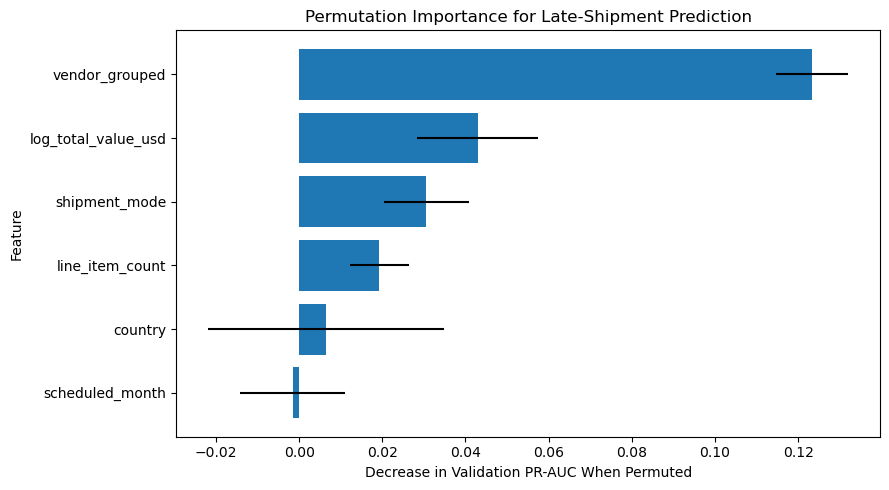

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance_mean"],
    xerr=feature_importance["importance_std"],
)

plt.gca().invert_yaxis()
plt.xlabel("Decrease in Validation PR-AUC When Permuted")
plt.ylabel("Feature")
plt.title("Permutation Importance for Late-Shipment Prediction")
plt.tight_layout()
plt.show()

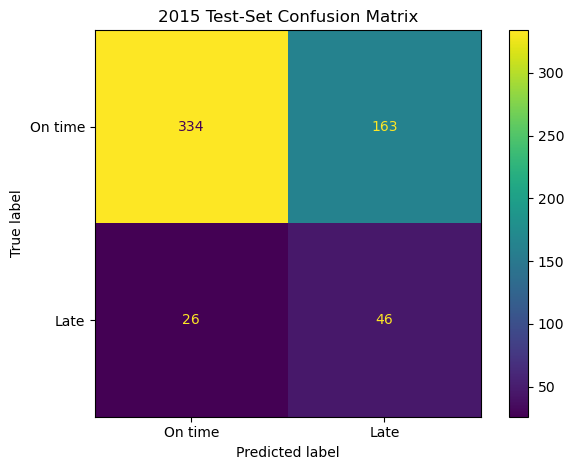

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    display_labels=["On time", "Late"],
    values_format="d",
)

plt.title("2015 Test-Set Confusion Matrix")
plt.tight_layout()
plt.show()

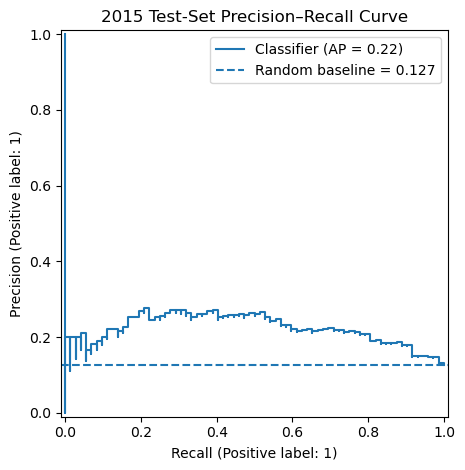

In [26]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(
    y_test,
    test_probabilities,
)

plt.axhline(
    y=y_test.mean(),
    linestyle="--",
    label=f"Random baseline = {y_test.mean():.3f}",
)

plt.title("2015 Test-Set Precision–Recall Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
from pathlib import Path

results_dir = Path("results")
figures_dir = Path("figures")

results_dir.mkdir(exist_ok=True)
figures_dir.mkdir(exist_ok=True)

pd.DataFrame([final_test_results]).to_csv(
    results_dir / "final_model_metrics.csv",
    index=False,
)

test_results.to_csv(
    results_dir / "test_shipment_predictions.csv",
    index=False,
)

feature_importance.to_csv(
    results_dir / "permutation_importance.csv",
    index=False,
)

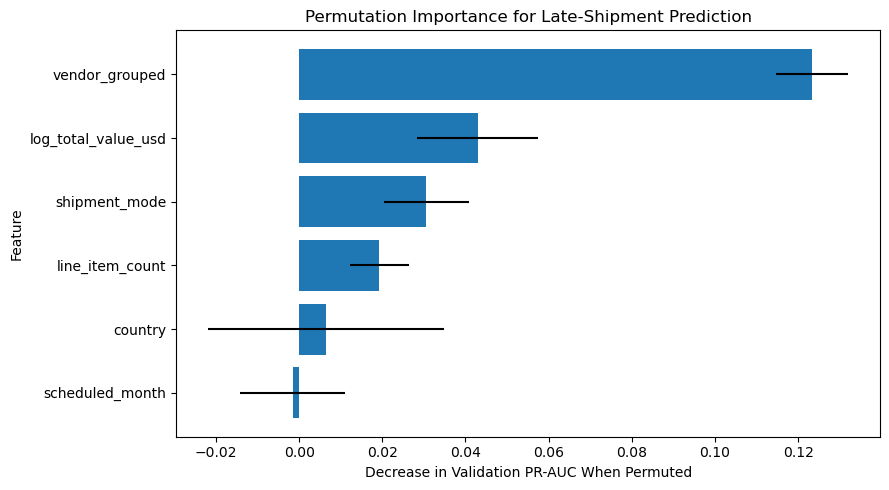

In [28]:
plt.figure(figsize=(9, 5))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance_mean"],
    xerr=feature_importance["importance_std"],
)

plt.gca().invert_yaxis()
plt.xlabel("Decrease in Validation PR-AUC When Permuted")
plt.ylabel("Feature")
plt.title("Permutation Importance for Late-Shipment Prediction")
plt.tight_layout()

plt.savefig(
    figures_dir / "permutation_importance.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

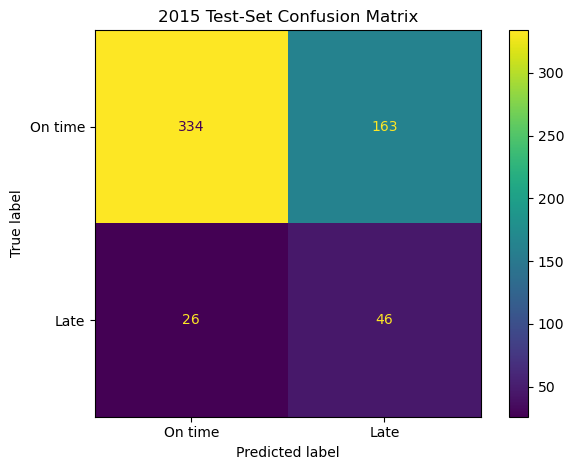

In [29]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    display_labels=["On time", "Late"],
    values_format="d",
)

plt.title("2015 Test-Set Confusion Matrix")
plt.tight_layout()

plt.savefig(
    figures_dir / "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

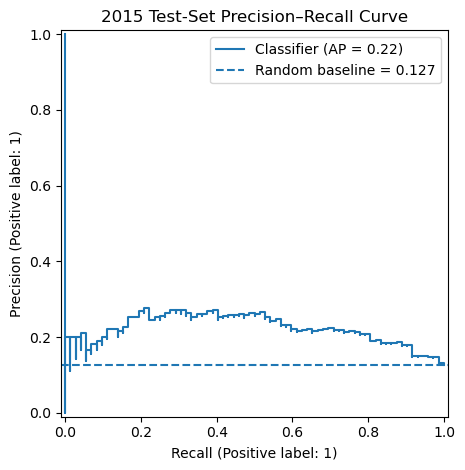

In [30]:
PrecisionRecallDisplay.from_predictions(
    y_test,
    test_probabilities,
)

plt.axhline(
    y=y_test.mean(),
    linestyle="--",
    label=f"Random baseline = {y_test.mean():.3f}",
)

plt.title("2015 Test-Set Precision–Recall Curve")
plt.legend()
plt.tight_layout()

plt.savefig(
    figures_dir / "precision_recall_curve.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()